In [ ]:
!pip install yfinance pandas-datareader

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
from pandas_datareader import data as pdr
import matplotlib.pyplot as plt

In [ ]:
yields = pdr.DataReader("DGS10", "fred", "2010-01-01")["DGS10"]
futures = yf.download("ZN=F", start="2010-01-01", progress=False, auto_adjust=False)["Close"]
if isinstance(futures, pd.DataFrame):
    futures = futures.iloc[:, 0]

data = pd.DataFrame({"yield": yields, "futures": futures}).dropna()
print(data.shape)
data.tail()

(4166, 2)


,yield,futures
2026-09-03,4.77,107.921875
2026-09-04,4.78,107.734375
2026-09-08,4.80,107.578125
2026-09-09,4.83,107.343750
2026-09-10,4.95,106.640625


In [ ]:
CTD_DURATION = 7.5
CASH_FACE = 10_000_000.0
CONTRACT_FACE = 100_000.0
FUTURES_POINT_VALUE = 1_000.0

cash_dv01 = CTD_DURATION * CASH_FACE * 0.0001
futures_dv01 = CTD_DURATION * CONTRACT_FACE * 0.0001
n_contracts = cash_dv01 / futures_dv01

df = data.copy()
df["cash_pnl"] = -cash_dv01 * df["yield"].diff() * 100.0
df["futures_pnl"] = -n_contracts * FUTURES_POINT_VALUE * df["futures"].diff()
df["pnl"] = df["cash_pnl"] + df["futures_pnl"]
df = df.dropna()

print(f"contracts short {n_contracts:.0f}")
print(f"leg correlation {df.cash_pnl.corr(df.futures_pnl):.3f}")
print(f"hedge reduction {1 - df.pnl.std() / df.cash_pnl.std():.1%}")


contracts short 100
leg correlation -0.930
hedge reduction 61.4%


In [ ]:
roll_months = [3, 6, 9, 12]
is_roll = df.index.month.isin(roll_months) & (df.index.day >= 18) & (df.index.day <= 26)
clean = df[~is_roll]

print(f"days removed    {is_roll.sum()}")
print(f"hedge reduction {1 - clean.pnl.std() / clean.cash_pnl.std():.1%}")
print(f"worst day       {clean.pnl.min():,.0f}")

days removed    401
hedge reduction 70.2%
worst day       -71,563


In [ ]:
fut_unit = df["futures"].diff() * FUTURES_POINT_VALUE
sub = pd.DataFrame({"cash": df["cash_pnl"], "fut": fut_unit}).loc[~is_roll].dropna()

n_fitted = np.cov(sub.cash, sub.fut)[0, 1] / np.var(sub.fut, ddof=1)
hedged = sub.cash - n_fitted * sub.fut

print(f"contracts, fitted       {n_fitted:.1f}  (vs {n_contracts:.0f} assumed)")
print(f"hedge reduction, fitted {1 - hedged.std() / sub.cash.std():.1%}")
print(f"hedge reduction, naive  {1 - clean.pnl.std() / clean.cash_pnl.std():.1%}")

contracts, fitted       93.3  (vs 100 assumed)
hedge reduction, fitted 71.0%
hedge reduction, naive  70.2%


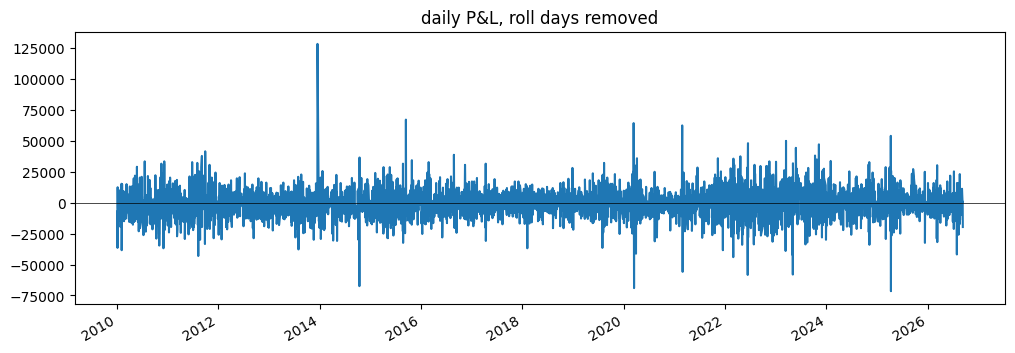

largest absolute moves:


,pnl
2013-12-17,128437.5
2025-04-10,71562.5
2020-03-16,69062.5
2014-10-15,67500.0
2015-09-15,67187.5
2020-03-13,64375.0
2021-02-26,62500.0
2022-06-13,58437.5
2023-05-04,58125.0
2021-03-01,55937.5


In [ ]:
clean["pnl"].plot(figsize=(12, 4), title="daily P&L, roll days removed")
plt.axhline(0, lw=0.5, color="black")
plt.show()

print("largest absolute moves:")
clean["pnl"].abs().nlargest(10)

In [ ]:
clean.to_csv("basis_pnl_clean.csv")
print(f"saved {len(clean)} rows")

saved 3764 rows


In [ ]:
!pip install arch

In [ ]:
from arch import arch_model

SCALE, BURN, REFIT = 1000.0, 500, 20

x = (clean["pnl"] / SCALE).values
N = len(x)
sigma2 = np.full(N, np.nan)
params = None

for t in range(BURN, N):
    if params is None or (t - BURN) % REFIT == 0:
        r = arch_model(x[:t], mean="Zero", vol="GARCH", p=1, q=1).fit(disp="off")
        params = (r.params["omega"], r.params["alpha[1]"], r.params["beta[1]"])
        if np.isnan(sigma2[t-1]):
            sigma2[t-1] = r.conditional_volatility[-1] ** 2
    omega, alpha, beta = params
    sigma2[t] = omega + alpha * x[t-1]**2 + beta * sigma2[t-1]

sigma = pd.Series(np.sqrt(sigma2), index=clean.index)
z = pd.Series(x, index=clean.index) / sigma
print(f"final params: omega {omega:.3f}, alpha {alpha:.3f}, beta {beta:.3f}")
print(f"out-of-sample sigma from {sigma.dropna().index[0].date()}")

final params: omega 12.475, alpha 0.115, beta 0.800
out-of-sample sigma from 2012-03-07


In [ ]:
WINDOW, CONF = 500, 0.99

zv = z.values
im = pd.Series(index=clean.index, dtype=float)

for t in range(BURN + WINDOW, len(zv)):
    pool = zv[t - WINDOW:t]
    im.iloc[t] = sigma.iloc[t] * np.quantile(-pool, CONF) * SCALE

im = im.dropna()
print(f"margin observations {len(im)}")
print(f"first margin date   {im.index[0].date()}")
print(f"mean IM  {im.mean():,.0f}")
print(f"min IM   {im.min():,.0f}")
print(f"max IM   {im.max():,.0f}")

margin observations 2764
first margin date   2014-06-06
mean IM  28,406
min IM   16,394
max IM   75,392


peak-to-trough ratio  4.60
largest 1-day rise    78.7%  on 2026-07-30
largest 5-day rise    173.9%  on 2021-03-02
breach rate           1.19%  (target 1.00%)


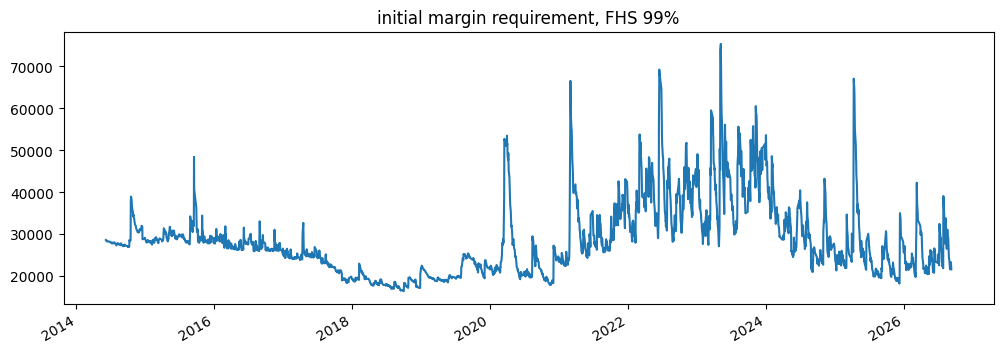

In [ ]:
d1 = im.diff() / im.shift()
d5 = im.diff(5) / im.shift(5)

print(f"peak-to-trough ratio  {im.max()/im.min():.2f}")
print(f"largest 1-day rise    {d1.max():.1%}  on {d1.idxmax().date()}")
print(f"largest 5-day rise    {d5.max():.1%}  on {d5.idxmax().date()}")

loss = -clean["pnl"].reindex(im.index)
print(f"breach rate           {(loss > im).mean():.2%}  (target 1.00%)")

im.plot(figsize=(12,4), title="initial margin requirement, FHS 99%")
plt.show()

In [ ]:
days_between = im.index.to_series().diff().dt.days
consecutive = days_between <= 4          # weekends fine, roll gaps not

d1_clean = d1[consecutive]
print(f"largest 1-day rise, gap-free  {d1_clean.max():.1%} on {d1_clean.idxmax().date()}")
print(f"dropped {(~consecutive).sum()} cross-gap observations")
print("\ntop 5 one-day rises:")
print((d1_clean.nlargest(5) * 100).round(1))

largest 1-day rise, gap-free  78.7% on 2026-07-30
dropped 50 cross-gap observations

top 5 one-day rises:
2026-07-30    78.7
2023-05-05    62.9
2021-03-01    62.8
2023-05-30    61.2
2022-06-14    60.8
dtype: float64


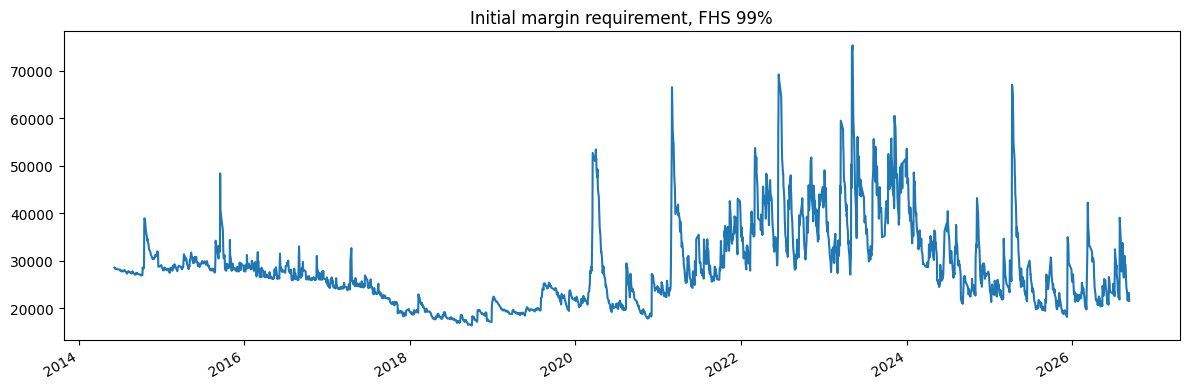

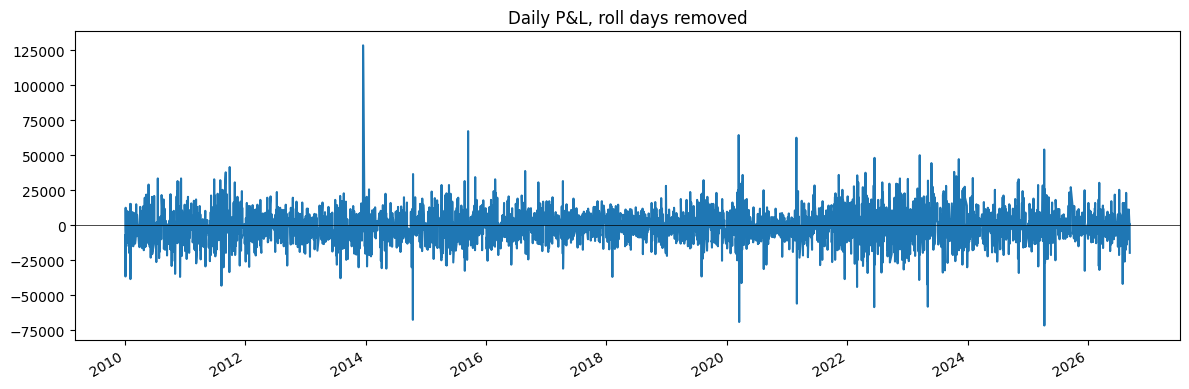

In [ ]:
import os
os.makedirs("figures", exist_ok=True)

im.plot(figsize=(12,4), title="Initial margin requirement, FHS 99%")
plt.tight_layout(); plt.savefig("figures/margin_path.png", dpi=120); plt.show()

clean["pnl"].plot(figsize=(12,4), title="Daily P&L, roll days removed")
plt.axhline(0, lw=0.5, color="black")
plt.tight_layout(); plt.savefig("figures/pnl.png", dpi=120); plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')